# Computer Vision for Autonomous Driving — Feature Extraction and Object Detection

# Feature Extraction for Autonomous Driving Perception

## What Is Feature Extraction?

Feature extraction is the process of identifying **important and distinctive patterns** in an image.

Instead of processing every pixel, autonomous driving perception systems focus on:
- Corners
- Edges
- Interest points
- Texture patterns

These features help self-driving vehicles:
- Recognize traffic signs, pedestrians, and other vehicles
- Match images across frames for visual odometry
- Track objects in real time on the road


## Why Feature Extraction Is Needed in Autonomous Driving

Raw pixel values:
- Are sensitive to noise from road vibrations and weather
- Change with lighting conditions (day, night, tunnels)
- Are too expensive to process in real time at highway speeds

Features provide:
- Compact representations for fast onboard processing
- Robustness to environmental changes
- Better performance for sign recognition, landmark matching, and localization


## Keypoints and Descriptors

A **keypoint** is a distinctive location in an image (e.g., corner or blob).

A **descriptor** is a numerical vector that describes the region around a keypoint.

In autonomous driving, they allow:
- Comparing consecutive camera frames for visual odometry
- Finding similar regions to re-identify landmarks
- Matching objects (signs, lane markers) across images from different viewpoints


## Classical Feature Detectors

Popular classical feature extraction methods include:
- SIFT (Scale-Invariant Feature Transform)
- SURF (Speeded-Up Robust Features)
- ORB (Oriented FAST and Rotated BRIEF)

In this lab, we use **ORB** because it is:
- Fast enough for real-time autonomous driving applications
- Free to use (no patent restrictions)
- Rotation invariant (handles vehicle turns and camera angles)
- Suitable for onboard embedded systems

Important:
> Classical feature detectors do **not** understand objects or meaning.  
> They respond only to **local intensity changes** in the image.

ORB detects **keypoints**, which are locations in the image with strong local contrast.

Each keypoint represents:
- **Location** (where the feature is)
- **Scale** (how large the feature is)
- **Orientation** (dominant direction)

ORB prefers:
- corners of traffic signs and buildings
- textured regions like road markings
- abrupt intensity changes at object boundaries

ORB avoids:
- smooth regions like clear sky
- uniform surfaces like blank walls
- heavily blurred areas from motion blur at high speed


In [ ]:
import cv2
import matplotlib.pyplot as plt

# Load the road lanes image (OpenCV loads images in BGR format)
img_bgr = cv2.imread('Image road lanes.jpg')

# Ensure the image was loaded correctly
if img_bgr is None:
    raise FileNotFoundError("Image not found. Check the file path.")

# Convert BGR to RGB for correct visualization
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display the original image
plt.imshow(img_rgb)
plt.title("Original Road Image")
plt.axis('off')
plt.show()

In [ ]:
# Convert original image to grayscale
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Create progressively blurred versions
blur_5  = cv2.GaussianBlur(img_gray, (9, 9), 0)     # mild blur
blur_25 = cv2.GaussianBlur(img_gray, (25, 25), 0)   # strong blur

# Display blurred versions
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(blur_5, cmap='gray')
plt.title("Mild Blur (9×9)")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(blur_25, cmap='gray')
plt.title("Strong Blur (25×25)")
plt.axis('off')

plt.tight_layout()
plt.show()

In [105]:
# Create ORB detector (limit number of features for clarity)
orb = cv2.ORB_create(nfeatures=500)

# Detect keypoints on each version
kp_orig, _  = orb.detectAndCompute(img_gray, None)
kp_blur5, _ = orb.detectAndCompute(blur_5, None)
kp_blur25,_ = orb.detectAndCompute(blur_25, None)

print("Keypoints (original):", len(kp_orig))
print("Keypoints (mild blur):", len(kp_blur5))
print("Keypoints (strong blur):", len(kp_blur25))


Keypoints (original): 500
Keypoints (mild blur): 395
Keypoints (strong blur): 49


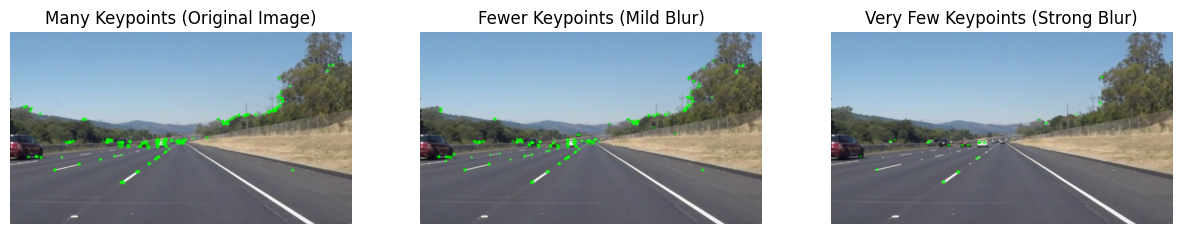

In [106]:
# Draw keypoints
img_kp_orig   = cv2.drawKeypoints(img_rgb, kp_orig, None, color=(0,255,0))
img_kp_blur5  = cv2.drawKeypoints(img_rgb, kp_blur5, None, color=(0,255,0))
img_kp_blur25 = cv2.drawKeypoints(img_rgb, kp_blur25, None, color=(0,255,0))

# Display comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_kp_orig)
plt.title("Many Keypoints (Original Image)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_kp_blur5)
plt.title("Fewer Keypoints (Mild Blur)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_kp_blur25)
plt.title("Very Few Keypoints (Strong Blur)")
plt.axis('off')

plt.show()


## What Do We Observe?

- The **original image** from the vehicle camera contains many local intensity changes → many keypoints.
- Mild blurring removes small details → fewer keypoints.
- Strong blurring (similar to motion blur at high speed) removes almost all local contrast → very few keypoints.

This demonstrates that:

> Classical feature detectors depend entirely on **local pixel variation**.

They do **not** understand:
- roads
- sky
- vehicles or pedestrians
- scene semantics

They only respond to **numerical differences** in pixel intensity — which is why modern autonomous driving systems combine them with deep learning.


### EXERCISE: Feature Detection Sensitivity

**Question:**  
Why does increasing blur (e.g., from motion blur at high vehicle speed) reduce the number of detected keypoints?

**Hint:**  
Think about how blur affects local intensity differences in a driving scene.


Blurring smooths intensity variations and removes local contrast.
Since ORB detects features based on pixel intensity differences,
fewer distinctive patterns remain, leading to fewer detected keypoints.

This is why high-speed driving and poor weather conditions (rain, fog) degrade classical feature detection in autonomous vehicles.


## Descriptors Explained

Keypoints tell us **where** interesting locations are in an image.

Descriptors tell us **what those locations look like**.

A **descriptor** is a numerical vector that encodes:
- local texture
- intensity patterns
- orientation information around a keypoint

In autonomous driving, descriptors allow us to:
- compare keypoints between images
- match the same physical point across views

For ORB specifically:

- Descriptors are **binary vectors**
- Each descriptor is a fixed-length vector
- Values are **0 or 1** (bits)
- Designed for fast comparison using Hamming distance
- Memory-efficient and suitable for real-time systems



In [107]:
# Number of keypoints detected
num_keypoints = len(keypoints)

print("Number of keypoints:", num_keypoints)

# Shape of descriptor array
# Rows    → one descriptor per keypoint
# Columns → length of each descriptor
print("Descriptor shape:", descriptors.shape)


Number of keypoints: 369
Descriptor shape: (369, 32)


## Limitations of Classical Features

Classical feature methods:
- Require manual design
- Struggle with complex scenes
- Fail under heavy occlusion
- Are sensitive to large appearance changes

These limitations motivated the use of **deep learning-based features** in modern autonomous driving perception systems.


## Key Takeaways

- Feature extraction identifies important patterns in driving scenes
- Keypoints represent locations of interest (signs, lane markers, objects)
- Descriptors encode local image information for frame-to-frame matching
- ORB provides fast and efficient feature extraction suitable for real-time autonomous driving


# Mini-Project B: Stop Sign Detection for Autonomous Vehicles

In this mini-project, we detect a **STOP sign** using **classical computer vision techniques** — a critical safety task for autonomous vehicles that must obey traffic regulations.
We visualize **every stage** so we can understand how the algorithm “thinks”.

Pipeline:
1. Original image from vehicle camera (RGB)
2. Convert to HSV color space
3. Threshold red color → binary mask
4. Morphological cleanup (open + dilate)
5. Segment red regions from the image
6. Binary threshold for contour extraction
7. Find contours (shapes)
8. Polygon approximation (detect octagon)
9. Bounding box, label, and crop

 Note:
Some functions used here are practical OpenCV tools.
You are NOT expected to memorize their implementation,
but you SHOULD understand:
- what goes in
- what comes out
- why we use them at this stage in the detection pipeline


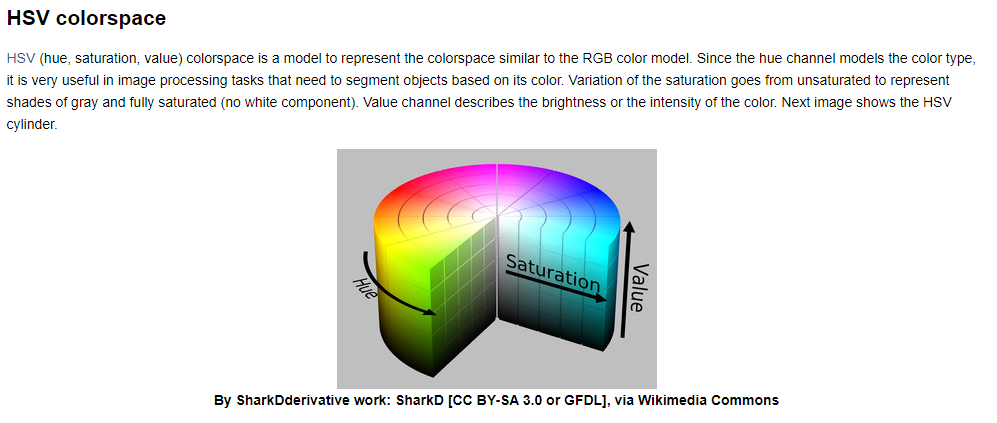

In RGB color space, each pixel is represented as a combination of three color channels: red, green, and blue. This means that any color can be created by varying the intensity of each channel. However, this representation does not separate brightness from color information. This can make it difficult to threshold an image based on color alone — for example, a stop sign may appear very different in direct sunlight vs. shade.

In contrast, HSV separates the color information into hue and saturation channels, and the brightness information into a separate value channel. This allows for more intuitive thresholding based on color and brightness separately. For example, an autonomous vehicle can threshold the hue channel to find red objects (like stop signs) regardless of whether it is a bright or cloudy day.

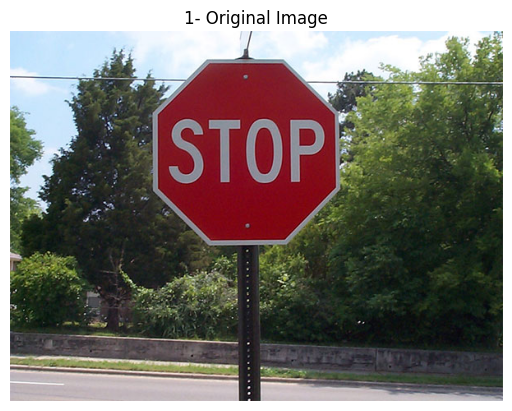

In [108]:
# Load the image from disk (OpenCV loads images in BGR format)
img_bgr = cv2.imread("/content/stop_sign_0.jpg")

# Safety check: ensure the image exists
if img_bgr is None:
    raise FileNotFoundError("Image not found. Check the file path.")

# Convert BGR to RGB for correct visualization in matplotlib
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Display the original image
plt.imshow(img_rgb)
plt.title("1️- Original Image")
plt.axis('off')
plt.show()


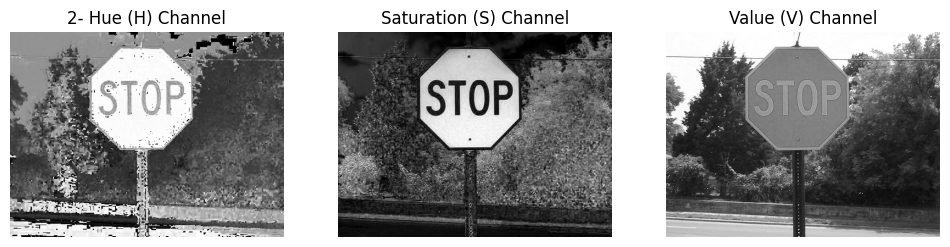

In [109]:
# Convert image from BGR to HSV color space
# HSV separates color (Hue) from brightness (Value),
# making color-based segmentation easier
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

# Split HSV channels for visualization and understanding
h, s, v = cv2.split(img_hsv)

# Display HSV channels side by side
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(h, cmap='gray')
plt.title("2️- Hue (H) Channel")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(s, cmap='gray')
plt.title("Saturation (S) Channel")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(v, cmap='gray')
plt.title("Value (V) Channel")
plt.axis('off')

plt.show()


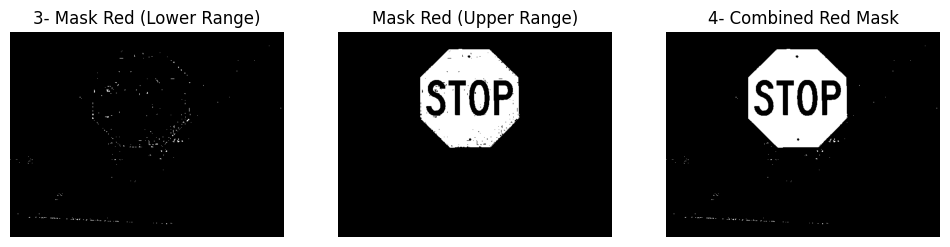

In [110]:
# Define lower red range in HSV (red wraps around hue boundary)
lower_red_1 = np.array([0, 110, 70])      # Lower hue band
upper_red_1 = np.array([30, 255, 255])

# Define upper red range in HSV
lower_red_2 = np.array([160, 120, 70])    # Upper hue band
upper_red_2 = np.array([180, 255, 255])

# inRange() performs pixel-wise thresholding
#
# For each pixel in HSV image:
# - If lower <= pixel <= upper → output = 255
# - Else → output = 0
#
# This creates a binary mask where:
# - White pixels represent RED regions
# - Black pixels represent everything else
mask_red_1 = cv2.inRange(img_hsv, lower_red_1, upper_red_1)
mask_red_2 = cv2.inRange(img_hsv, lower_red_2, upper_red_2)

# Combine both red masks into one
mask_red = cv2.bitwise_or(mask_red_1, mask_red_2)

# Display masks
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(mask_red_1, cmap='gray')
plt.title("3️- Mask Red (Lower Range)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_red_2, cmap='gray')
plt.title("Mask Red (Upper Range)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mask_red, cmap='gray')
plt.title("4️- Combined Red Mask")
plt.axis('off')

plt.show()


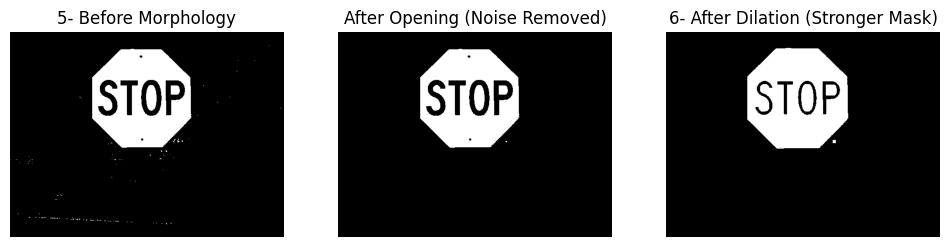

In [132]:
# Create a small kernel for morphology
kernel_small = np.ones((3, 3), np.uint8)


# morphologyEx() applies a sequence of erosion/dilation
#
# MORPH_OPEN:
# - Erosion → removes small noise
# - Dilation → restores main shapes
#
# This cleans the binary mask so contours become stable

mask_open = cv2.morphologyEx(mask_red, cv2.MORPH_OPEN, kernel_small)

# Create a larger kernel to strengthen the mask
kernel_large = np.ones((5, 5), np.uint8)

# Dilation expands white regions
# Purpose:
# - Fill small holes
# - Make contours more stable
mask_clean = cv2.morphologyEx(mask_open, cv2.MORPH_DILATE, kernel_large)

# Visualize morphology stages
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(mask_red, cmap='gray')
plt.title("5️- Before Morphology")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_open, cmap='gray')
plt.title("After Opening (Noise Removed)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mask_clean, cmap='gray')
plt.title("6️- After Dilation (Stronger Mask)")
plt.axis('off')

plt.show()


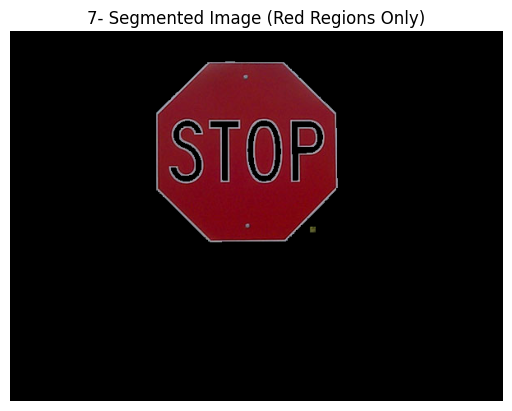

In [133]:
# bitwise_and():
# - Keeps original pixels where mask == 255
# - Removes everything else
segmented = cv2.bitwise_and(img_rgb, img_rgb, mask=mask_clean)

# Display segmented result
plt.imshow(segmented)
plt.title("7️- Segmented Image (Red Regions Only)")
plt.axis('off')
plt.show()


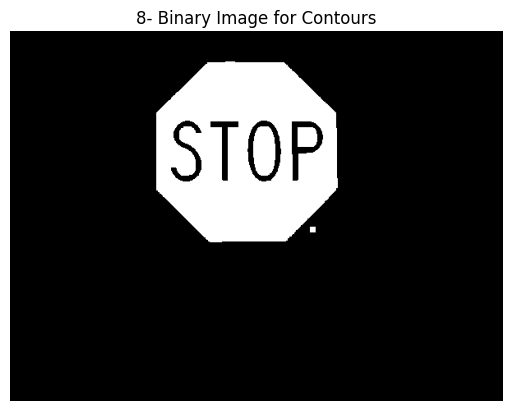

In [134]:
# Convert segmented image back to HSV to use Value channel
seg_hsv = cv2.cvtColor(cv2.cvtColor(segmented, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2HSV)

# Extract brightness (Value) channel
_, _, seg_v = cv2.split(seg_hsv)

# Convert to binary image
# Required for contour detection:
# - background = black
# - object = white
_, thresh = cv2.threshold(seg_v, 0, 255, cv2.THRESH_BINARY)

# Display thresholded image
plt.imshow(thresh, cmap='gray')
plt.title("8️- Binary Image for Contours")
plt.axis('off')
plt.show()


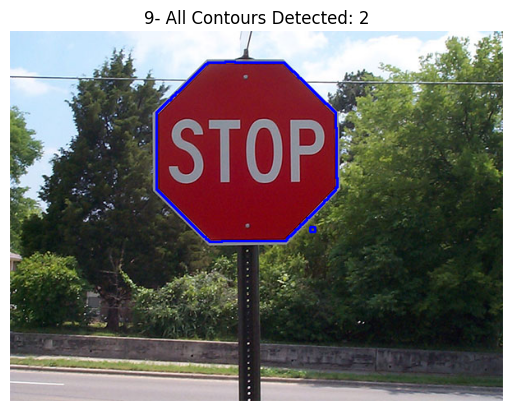

In [135]:
# findContours() detects continuous white regions in a binary image
#
# Requirements:
# - Background must be black (0)
# - Objects must be white (255)
#
# RETR_EXTERNAL:
# - Only outermost contours
#
# CHAIN_APPROX_SIMPLE:
# - Compresses horizontal/vertical points
#
# Output:
# - contours: list of point arrays (each contour is a shape)

contours, hierarchy = cv2.findContours(
    thresh.copy(),
    cv2.RETR_EXTERNAL,       # Only outer contours
    cv2.CHAIN_APPROX_SIMPLE  # Compress redundant points
)

# Visualize all detected contours
contour_vis = img_rgb.copy()
cv2.drawContours(contour_vis, contours, -1, (0, 0, 255), 2)

plt.imshow(contour_vis)
plt.title(f"9️- All Contours Detected: {len(contours)}")
plt.axis('off')
plt.show()


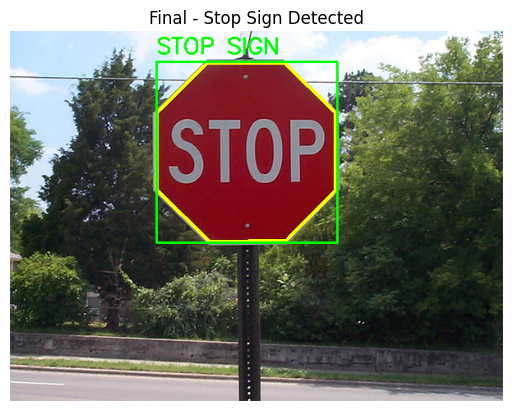

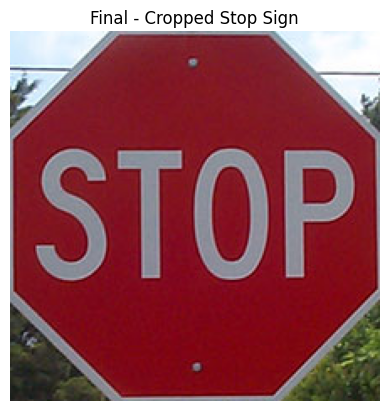

In [115]:
# Copy image for final visualization
detected_vis = img_rgb.copy()

# Store detected bounding box
best_box = None

# Loop through contours
for cnt in contours:
    # Compute contour perimeter
    perimeter = cv2.arcLength(cnt, True)

    # approxPolyDP() approximates a contour using fewer points
    #
    # epsilon controls approximation accuracy:
    # - Smaller epsilon → more detailed shape
    # - Larger epsilon → simpler shape
    #
    # We use it to detect geometric shapes
    # Stop sign ≈ octagon → 8 vertices
    approx = cv2.approxPolyDP(cnt, 0.01 * perimeter, True)

    # Stop sign ≈ octagon → 8 sides
    if len(approx) == 8:
        # boundingRect() computes the smallest upright rectangle
        # that fully contains the contour
        #
        # Returns:
        # - x, y: top-left corner
        # - w, h: width and height
        #
        # Used for:
        # - Localization
        # - Cropping
        # - Size and aspect-ratio filtering
        x, y, w, h = cv2.boundingRect(cnt)

        # Aspect ratio filter (stop sign is nearly square)
        aspect_ratio = w / float(h)

        # Size filter to ignore tiny detections
        if 0.8 <= aspect_ratio <= 1.2 and w > int(img_rgb.shape[1] / 10):
            best_box = (x, y, w, h)

            # Draw polygon approximation
            cv2.drawContours(detected_vis, [approx], -1, (255, 255, 0), 3)

            # Draw bounding box
            cv2.rectangle(detected_vis, (x, y), (x + w, y + h), (0, 255, 0), 2)

            # putText() draws text on an image
            #
            # Used only for visualization / debugging
            # Has no effect on detection logic
            cv2.putText(
                detected_vis,
                "STOP SIGN",
                (x, y - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.9,
                (0, 255, 0),
                2
            )

# Show final detection result
plt.imshow(detected_vis)
plt.title("Final - Stop Sign Detected")
plt.axis('off')
plt.show()

# Crop detected stop sign if found
if best_box is not None:
    x, y, w, h = best_box
    crop = img_rgb[y:y+h, x:x+w]

    plt.imshow(crop)
    plt.title("Final - Cropped Stop Sign")
    plt.axis('off')
    plt.show()
else:
    print("No valid stop sign detected. Try adjusting HSV or morphology parameters.")


## Why This Works (and When It Fails)

✔ HSV separates color from brightness  
✔ Morphology stabilizes binary masks  
✔ Contours convert masks into shapes  
✔ Polygon approximation enables shape reasoning  

Failure cases in real driving scenarios:
- Poor lighting (tunnels, nighttime driving)
- Faded or occluded signs (partially hidden by trees or snow)
- Background objects with similar red color (taillights, red buildings)
- Motion blur at high vehicle speeds

This pipeline shows how **classical computer vision reasons step by step** — and why modern autonomous vehicles supplement it with deep learning for reliability.


# Homework: School Crossing Sign Detection

**Objective:** Apply classical computer vision to detect a school crossing sign.

## Steps to follow:
1. **Load and Display**: Read the image `School crossing 2.jpg` from disk.
2. **HSV Conversion & Masking**: Convert to HSV. School crossing signs are typically fluorescent yellow-green. We will use a Hue range of approximately `[20, 50]` to capture this color.
3. **Morphological Operations**: Use closing to fill in small holes in the mask (e.g., the black icons on the sign) and opening to remove small noise in the background. A kernel size of `5x5` is usually a good starting point, but we may adjust it.
4. **Segmentation**: Apply a bitwise AND to extract the sign's original colors.
5. **Contour Detection & Filtering**: Find contours. Filter by area to ignore tiny speckles. We will also use `cv2.approxPolyDP()` to approximate the shape. A school crossing sign is a pentagon, so we look for polygons with ~5 vertices.
6. **Bounding Box**: Draw a rectangle around the detected contour.


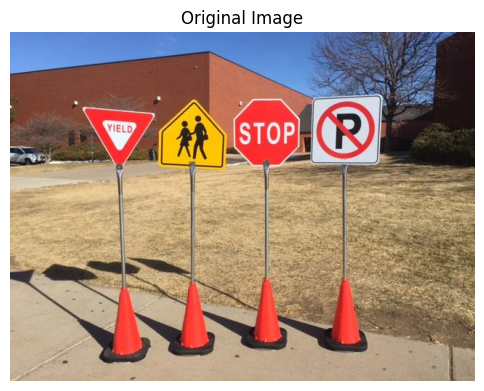

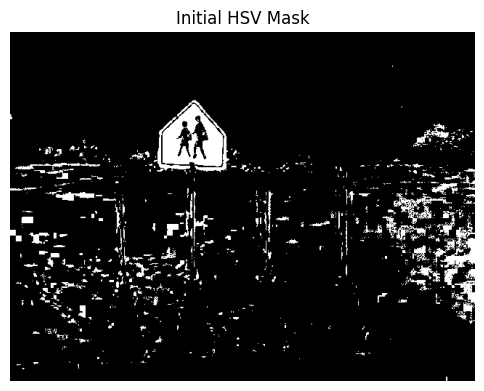

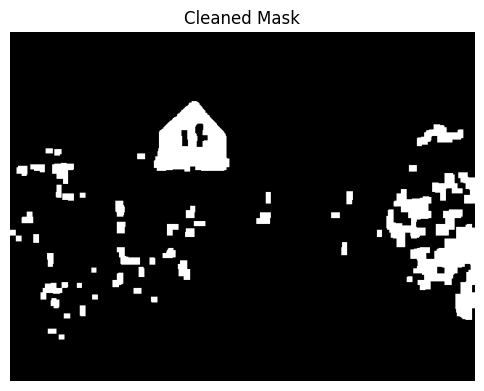

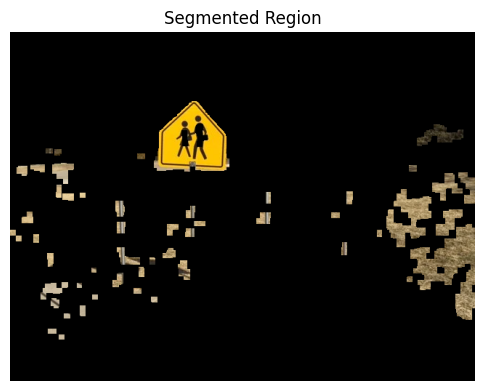

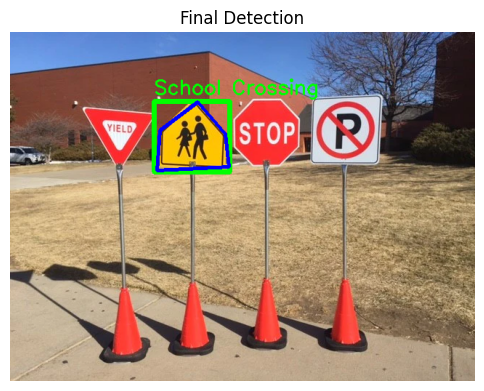

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Helper function to display images
def imshow(title, img, cmap=None):
    plt.figure(figsize=(6, 6))
    plt.title(title)
    if cmap:
        plt.imshow(img, cmap=cmap)
    else:
        # OpenCV uses BGR, matplotlib uses RGB
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# 1. Load the provided school crossing sign image
image_path = 'School crossing 2.jpg'
image = cv2.imread(image_path)
if image is None:
    print(f"Error: Could not load image at {image_path}")
else:
    imshow("Original Image", image)

    # 2 & 3. Convert to HSV and create mask for fluorescent yellow-green
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    # Fluorescent yellow/green roughly corresponds to Hue 20-45
    lower_bound = np.array([20, 50, 50])
    upper_bound = np.array([45, 255, 255])
    mask = cv2.inRange(hsv, lower_bound, upper_bound)
    imshow("Initial HSV Mask", mask, cmap='gray')

    # 4. Apply morphological operations
    # We use closing to fill the black inner drawings (stick figures)
    # and opening to remove small background noise
    kernel = np.ones((7,7), np.uint8)
    cleaned_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_OPEN, kernel)
    imshow("Cleaned Mask", cleaned_mask, cmap='gray')

    # 5. Segment the sign from the background
    segmented = cv2.bitwise_and(image, image, mask=cleaned_mask)
    imshow("Segmented Region", segmented)

    # 6. Detect contours and filter by area and shape (pentagon)
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    output_image = image.copy()
    sign_detected = False
    for cnt in contours:
        area = cv2.contourArea(cnt)
        # Filter by minimum area
        if area > 1000:
            # Approximate the polygon
            peri = cv2.arcLength(cnt, True)
            # The epsilon value controls how much the polygon is smoothed
            approx = cv2.approxPolyDP(cnt, 0.03 * peri, True)
            
            # A school crossing sign is a pentagon, so we check for approx 5 sides.
            # Depending on perspective or noise, it might be 4-6, so we allow some tolerance
            if len(approx) == 5:
                # 7. Draw bounding box on original image
                x, y, w, h = cv2.boundingRect(cnt)
                cv2.rectangle(output_image, (x, y), (x+w, y+h), (0, 255, 0), 5)
                cv2.putText(output_image, "School Crossing", (x, y - 10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
                sign_detected = True
                # Draw the approximated contour points for visualization
                cv2.drawContours(output_image, [approx], -1, (255, 0, 0), 3)

    if sign_detected:
        imshow("Final Detection", output_image)
    else:
        print("No sign detected. Try tuning the HSV bounds or morphological operations.")
